# **Data Mining & Foundations of AI (Assessment 2)**

# Student number: 100191919

# **Training an image categorisation model to identify pneumonia in chest x-rays** 

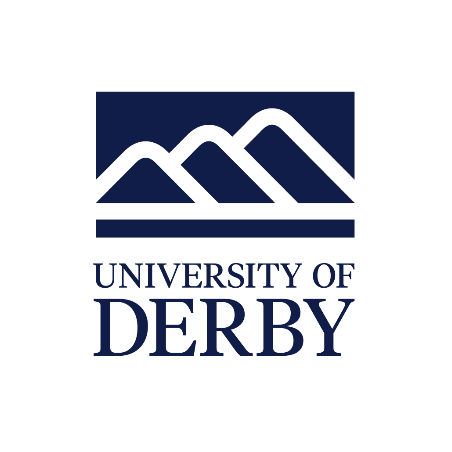

---

# **Introduction**
In this and the accompanying pre-processing notebook I will fine tune an existing image classification model to identify pneumonia in the sample dataset. I will explain my testing with data pre-processing, the two different models I tired, and how I achieved my final result of 98% accuracy. 

The dataset used was downloaded from Kaggle.



https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


# **Dataset**
The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal). To run this notebook the dataset should be extracted to "./chest_xray/raw/". Running the pre-processing notebook will create "./chest_xray/PROCESSED-1.0/".

RUNNING THE PRE-PROCESSING IS NOT REQUIRED.

Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.

For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.

In [106]:
import os
import itertools
import glob
import random

import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lime import lime_image
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from skimage.segmentation import mark_boundaries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator


print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

TensorFlow Version: 2.10.0
Keras Version: 2.10.0
Num GPUs Available:  2


Getting GPU acceleration working locally was absolutely frustrating. First I started with CPU only which worked however was quite slow. I followed the tensorflow docs to enable cuda installing the correct versions of cuda and tensorflow. This didn't work well as it didn't release memory after each run and consumed all my GPU memory, then system ram. This resulted in very poor performance after exhausting GPU memory. This can be seen by how uneven the GPU compute utilisation is in the below picture. When the working data is loaded into VRAM GPU utilisation is a constantly 100% for the duration of training. 



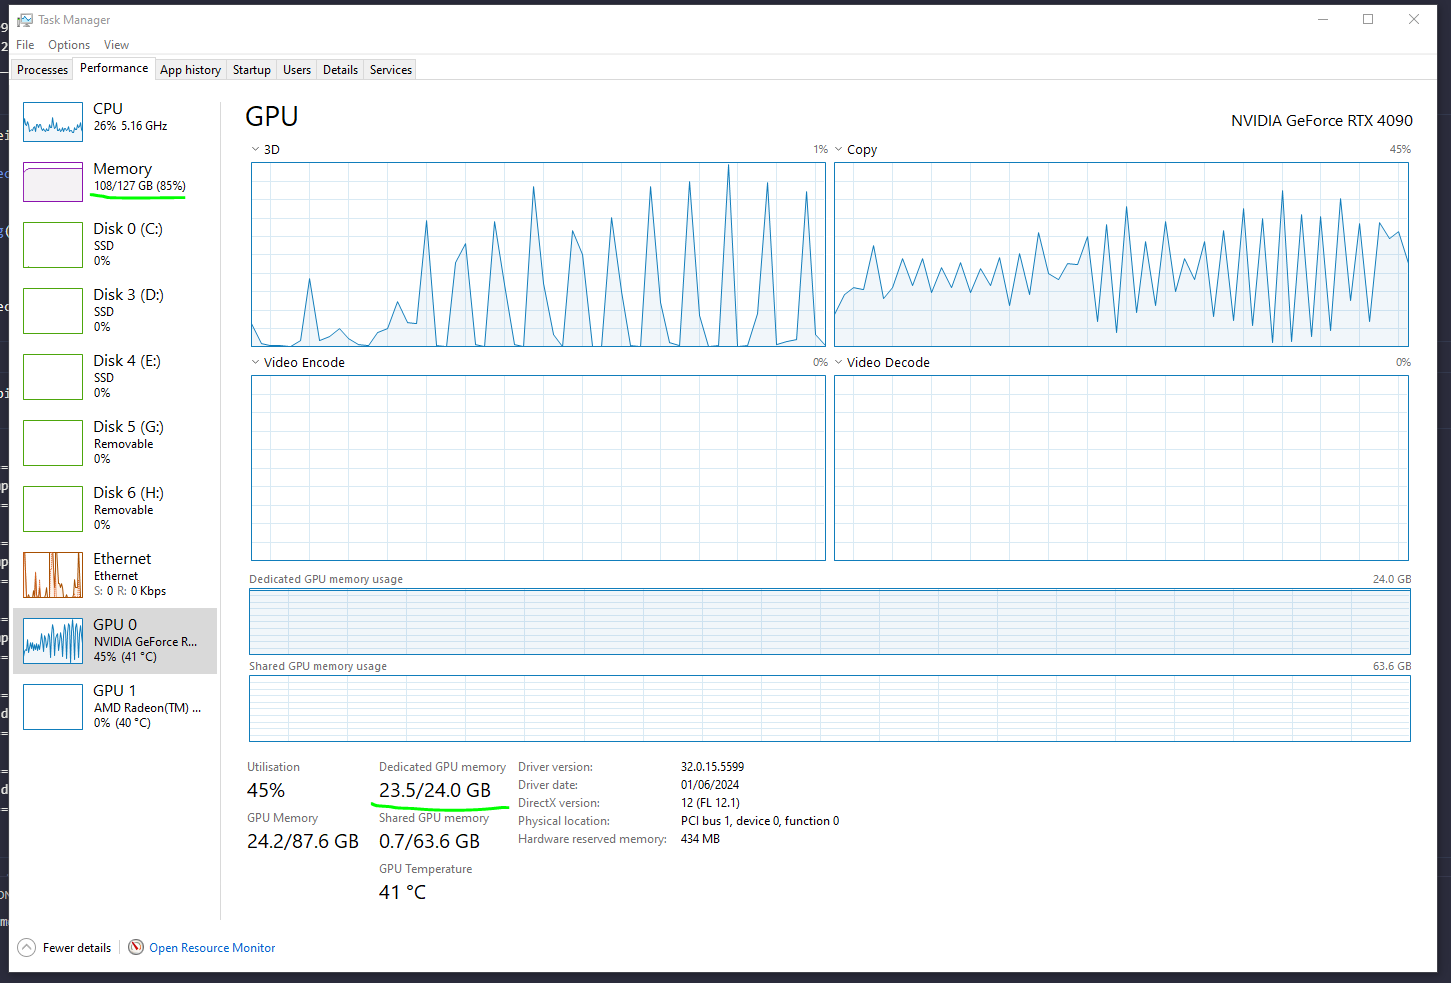


After a day of debugging I decided to return to CPU and abandon cuda. I didn't however note down the versions of libraries I was using beforehand and after another day of debugging a cell which took 20 mins to run before now took 120 mins on CPU. Finally, I asked a friend to run my notebook and that cell took them 2 mins to run. I asked them to use pipreqs to create a requirements.txt and note down the version of cuda. None of that they used matched the docs however after creating a new venv and matching their cuda version GPU acceleration finally worked as expected after three days of trial and error. I tried to generate a requirements.txt but it doesn't seem to be commplete. I've also included fullrequirements.txt which was supplied by my friend but he didn't use a venv so there's a lot of unneeded packages.

https://www.tensorflow.org/install/pip

https://www.tensorflow.org/guide/gpu



In [107]:
def create_dataframe(data_dir):
    # Create a list of filepaths and labels and return a DataFrame

    filepaths = []
    labels = []

    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            if file.startswith('.'):
                continue
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)

    # Concatenate data paths with labels into one dataframe
    Fseries = pd.Series(filepaths, name= 'filepaths')
    Lseries = pd.Series(labels, name='label')
    df = pd.concat([Fseries, Lseries], axis= 1)
    return df

def test_model(test_gen, model):
    # tests the model on the test set and returns the predicted labels

    steps = len(test_gen)
    preds = model.predict(test_gen, steps= steps, verbose= 1)
    y_pred = np.argmax(preds, axis=1)
    return y_pred

def display_data_preview(df):
    # Display a preview of a dataframe in a plot

    num_images=9
    # Randomly sample num_images from the DataFrame
    sampled_df = df.sample(n=num_images).reset_index(drop=True)

    plt.figure(figsize=(7, 5))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)

        # Read the image
        img_path = sampled_df.iloc[i]['filepaths']
        img = plt.imread(img_path)

        plt.imshow(img,cmap='gray')
        plt.title(sampled_df.iloc[i]['label'])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def display_test_confusion_matrix(test_gen, y_pred, classes):
    # Display the confusion matrix of the models classification performance

    # Confusion matrix
    cm = confusion_matrix(test_gen.classes, y_pred)

    plt.figure(figsize= (10, 10))
    plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation= 45)
    plt.yticks(tick_marks, classes)


    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.show()

def display_training_history(history, accuracy_metric):
    # Display the training history of the model
    
    tr_acc = history.history[accuracy_metric]
    tr_loss = history.history['loss']
    val_acc = history.history['val_' + accuracy_metric]
    val_loss = history.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()

Throughout this process I did a lot of testing with pre-processing both in the raw training data and when creating the ImageDataGenerator later on. I consistently found pre-processing the training data yielded poorer model performance. The images needed to be 1.0 aspect ratio so I tired cropping to focus on the centre of the image. I also tested shear and rotation. In the end rescaling the pixel values to between 0 and 1 then letting the ImageDataGenerator scale the image yielded the best performance. I think cropping the images had the potential to remove the pneumonia from positive images confusing the training. While changing the aspect ratio of the images distorted them it was more important to retain all of the image.

In [108]:

data_dir='chest_xray\\raw'
#data_dir='chest_xray\\PROCESSED-1.0'
#data_dir='chest_xray\\PROCESSED-1.0-rotated'

paths=glob.glob(data_dir+'/*/*/*.jpeg')
print(f'found {len(paths)} images in the dataset')
paths[:5]


found 5856 images in the dataset


['chest_xray\\raw\\test\\NORMAL\\IM-0001-0001.jpeg',
 'chest_xray\\raw\\test\\NORMAL\\IM-0003-0001.jpeg',
 'chest_xray\\raw\\test\\NORMAL\\IM-0005-0001.jpeg',
 'chest_xray\\raw\\test\\NORMAL\\IM-0006-0001.jpeg',
 'chest_xray\\raw\\test\\NORMAL\\IM-0007-0001.jpeg']

In [109]:
df=pd.DataFrame(paths,columns=['filepaths'])
df

,filepaths
0,chest_xray\raw\test\NORMAL\IM-0001-0001.jpeg
1,chest_xray\raw\test\NORMAL\IM-0003-0001.jpeg
2,chest_xray\raw\test\NORMAL\IM-0005-0001.jpeg
3,chest_xray\raw\test\NORMAL\IM-0006-0001.jpeg
4,chest_xray\raw\test\NORMAL\IM-0007-0001.jpeg
...,...
5851,chest_xray\raw\val\PNEUMONIA\person1949_bacter...
5852,chest_xray\raw\val\PNEUMONIA\person1950_bacter...
5853,chest_xray\raw\val\PNEUMONIA\person1951_bacter...
5854,chest_xray\raw\val\PNEUMONIA\person1952_bacter...


In [110]:
df['label']=df['filepaths'].apply(lambda x:x.split('\\')[3].strip())
df

,filepaths,label
0,chest_xray\raw\test\NORMAL\IM-0001-0001.jpeg,NORMAL
1,chest_xray\raw\test\NORMAL\IM-0003-0001.jpeg,NORMAL
2,chest_xray\raw\test\NORMAL\IM-0005-0001.jpeg,NORMAL
3,chest_xray\raw\test\NORMAL\IM-0006-0001.jpeg,NORMAL
4,chest_xray\raw\test\NORMAL\IM-0007-0001.jpeg,NORMAL
...,...,...
5851,chest_xray\raw\val\PNEUMONIA\person1949_bacter...,PNEUMONIA
5852,chest_xray\raw\val\PNEUMONIA\person1950_bacter...,PNEUMONIA
5853,chest_xray\raw\val\PNEUMONIA\person1951_bacter...,PNEUMONIA
5854,chest_xray\raw\val\PNEUMONIA\person1952_bacter...,PNEUMONIA


The dataset was delivered pre-split into training, testing and validation sets. The sets however where very unbalanced and using the provided split consistently resulted in very poor performance. Merging all the data then resplitting ensured randomness and allowed me to rebalance the splits. The pre-split data had 624 images in the testing set to be used during training which is mess than the 586 after manually splitting. It is clear that the original split wasn't lacking in quanity but quality. This significantly improved image classification performance and almost certainly improved the performance of model accuracy validation.

In [174]:
# Splitting data
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)

#train_df = create_dataframe('chest_xray\\PROCESSED-1.0\\train')
#test_df = create_dataframe('chest_xray\\PROCESSED-1.0\\test')
#val_df = create_dataframe('chest_xray\\PROCESSED-1.0\\val')

print("Training set shapes:", train_df.shape)
print("Validation set shapes:", val_df.shape)
print("Testing set shapes:", test_df.shape)

Training set shapes: (4684, 2)
Validation set shapes: (586, 2)
Testing set shapes: (586, 2)


Re-balacing the dataset removing the strong bias for positive images improved the tendency for the models to give false positives giving more accurate results.

In [172]:
df_penu = train_df[train_df.label == 'PNEUMONIA']
df_norm = train_df[train_df.label == 'NORMAL']

print(f"Pneumonia: {df_penu.shape[0]}")
print(f"Normal: {df_norm.shape[0]}")

Pneumonia: 3432
Normal: 1252


In [168]:
df_majority_downsampled = resample(df_penu,
                                   replace=False,  
                                   n_samples=len(df_norm),
                                   random_state=42)  

# Combine minority class with downsampled majority class
train_df = pd.concat([df_norm, df_majority_downsampled])

train_df['label'].value_counts()

label
NORMAL       1252
PNEUMONIA    1252
Name: count, dtype: int64

While trying to improve performance I decided to restructure the data to binary classification opposed to categorical classification. This made sense as the data is positive or negative which is binary. I made this chance as a precursor for changing to binary_crossentropy. Despite not fully implementing it due to the shape of the models it did offer marginal performance improvement in the second model.

In [113]:
train_df_binary = train_df.copy()
test_df_binary = test_df.copy()
val_df_binary = val_df.copy()

train_df_binary['label'] = train_df['label'].apply(lambda x: '1' if x == 'PNEUMONIA' else '0')
test_df_binary['label'] = test_df['label'].apply(lambda x: '1' if x == 'PNEUMONIA' else '0')
val_df_binary['label'] = val_df['label'].apply(lambda x: '1' if x == 'PNEUMONIA' else '0')
train_df_binary['label'].value_counts()

label
0    1252
1    1252
Name: count, dtype: int64

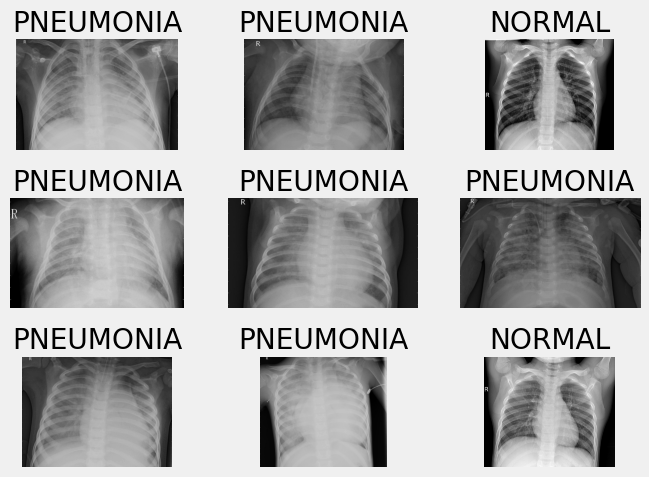

In [114]:
display_data_preview(train_df)

An optimisation I feel would be worth trying would be using one channel for the images by converting them to grayscale. the dataset is already black and white so the three RGB channels aren't necessary. This would reduce the size of the dataset improving processing speed and may give better results. This would require changing the input shape of the models.

In [115]:
batch_size = 16
img_size = (224, 224)
img_size_small = (150, 150)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

#clamp pixel values to the range [0, 1]
tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen = tr_gen.flow_from_dataframe(train_df, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe(val_df, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

train_gen_binary = tr_gen.flow_from_dataframe(train_df_binary, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'binary',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen_binary = ts_gen.flow_from_dataframe(val_df_binary, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'binary',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen_binary = ts_gen.flow_from_dataframe(test_df_binary, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'binary',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

g_dict = test_gen.class_indices
classes = list(g_dict.keys())

g_dict = test_gen_binary.class_indices
classes_binary = list(g_dict.keys())

Found 2504 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.
Found 2504 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.


EfficientNetB0 is the first model I tried to implement. Studying notebooks on Kaggle I researched how they worked and verified they ran locally. If needed I modified them to work with dataframes as data ingest varied between the notebooks I looked at. This model did not respond to changes in pre-processing, learning rates or dropout rate. I was unable to replicate the origional creators seemingly good results. I do not believe this was due to the training and validation data as I compared data ingest and pre-processing carefully in the initial stages of debugging. I did briefly consider switching from EfficientNetB0 to EfficientNetB5 or higher which has larger input shape. This would mean I could use higher resolution input images and potentially achieve better peformance. After seeing the poor performance in the training graphs I decided to move on as I don't believe it would have helped the situation.

In [116]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')

model1 = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2(0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model1.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model1.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 1280)             4049571   
                                                                 
 batch_normalization_3 (Batc  (None, 1280)             5120      
 hNormalization)                                                 
                                                                 
 dense_11 (Dense)            (None, 256)               327936    
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                                 
 dense_12 (Dense)            (None, 2)                 514       
                                                                 
Total params: 4,383,141
Trainable params: 4,338,558
Non-trainable params: 44,583
_______________________________________

In [117]:
history1 = model1.fit(
    x=train_gen, 
    epochs=10, 
    verbose=1, 
    validation_data=valid_gen, 
    validation_steps=None, 
    shuffle=False
    )

Epoch 1/10
157/157 [==============================] - 29s 141ms/step - loss: 5.7535 - accuracy: 0.8950 - val_loss: 4.8725 - val_accuracy: 0.2850
Epoch 2/10
157/157 [==============================] - 21s 133ms/step - loss: 3.4475 - accuracy: 0.9353 - val_loss: 3.2168 - val_accuracy: 0.7184
Epoch 3/10
157/157 [==============================] - 21s 133ms/step - loss: 2.2869 - accuracy: 0.9653 - val_loss: 2.9665 - val_accuracy: 0.7184
Epoch 4/10
157/157 [==============================] - 21s 132ms/step - loss: 1.5976 - accuracy: 0.9724 - val_loss: 1.7063 - val_accuracy: 0.7099
Epoch 5/10
157/157 [==============================] - 21s 136ms/step - loss: 1.1423 - accuracy: 0.9756 - val_loss: 1.4749 - val_accuracy: 0.7150
Epoch 6/10
157/157 [==============================] - 21s 131ms/step - loss: 0.8117 - accuracy: 0.9788 - val_loss: 1.3076 - val_accuracy: 0.7150
Epoch 7/10
157/157 [==============================] - 21s 131ms/step - loss: 0.5973 - accuracy: 0.9852 - val_loss: 0.9053 - val_ac

Over multiple runs the validation loss and validation accuracy this model wasn't even close to performing well which was a large factor in my decision to move on. More epochs wouldn't help improve the situation.

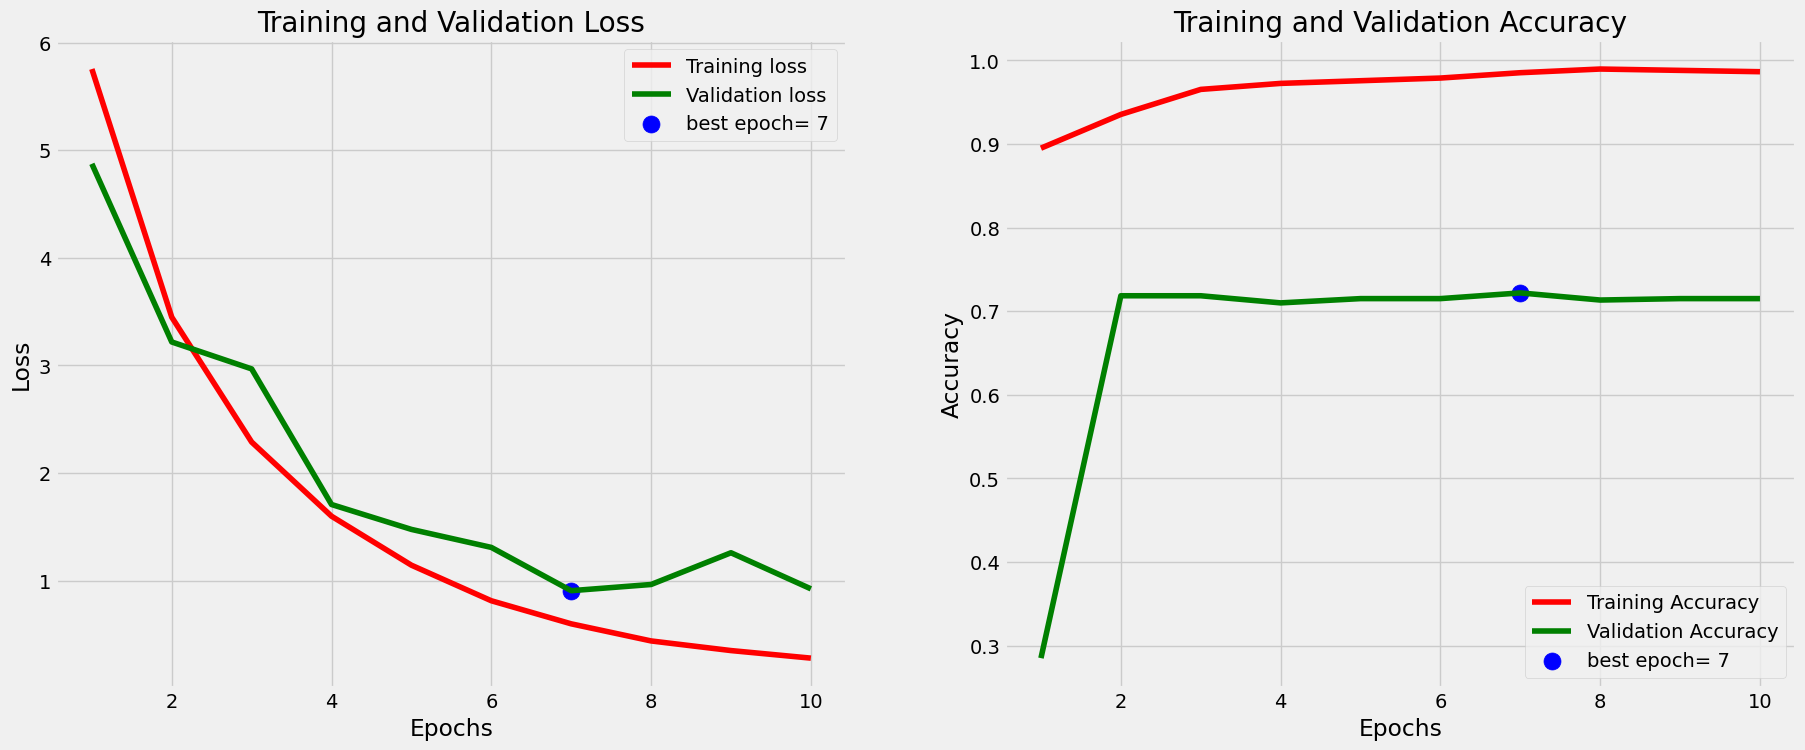

In [118]:
display_training_history(history1, "accuracy")

In [119]:
y_pred1 = test_model(test_gen, model1)

293/293 [==============================] - 5s 13ms/step


In [120]:
model1.evaluate(test_gen)

293/293 [==============================] - 4s 13ms/step - loss: 0.9297 - accuracy: 0.7201


[0.9296581745147705, 0.7201365232467651]

In [121]:
print(classification_report(test_gen.classes, y_pred1, target_names=classes, zero_division=0))

              precision    recall  f1-score   support

      NORMAL       0.50      0.01      0.01       164
   PNEUMONIA       0.72      1.00      0.84       422

    accuracy                           0.72       586
   macro avg       0.61      0.50      0.42       586
weighted avg       0.66      0.72      0.61       586



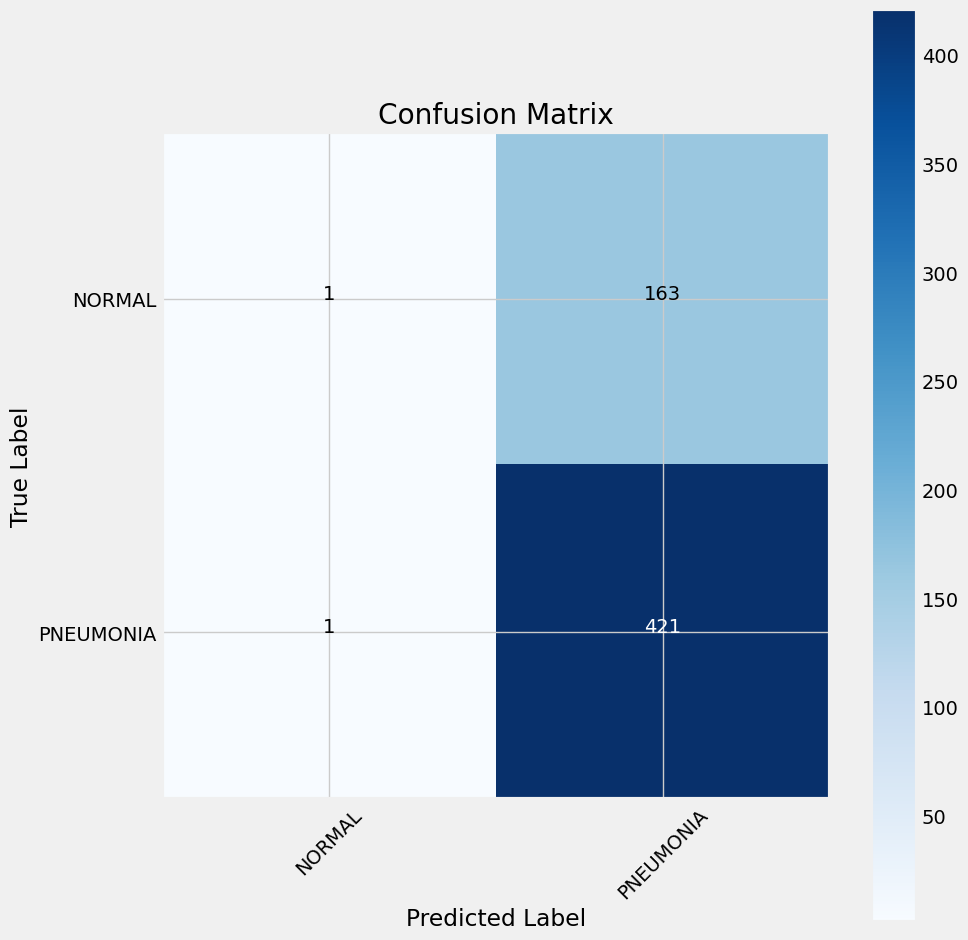

In [122]:
display_test_confusion_matrix(test_gen, y_pred1, classes)

In [123]:
vgg19 = tf.keras.applications.VGG19(include_top=True)
vgg19_clone = tf.keras.models.clone_model(vgg19)
vgg19_clone.set_weights(vgg19.get_weights())

vgg19_clone.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

The second model I implemented is VGG19, another pre trained classification model we will fine tune. This model has more layers, more parameters and when combined with the two step training approach I expect better performance. It didn't work out of the gate. I did a lot of testing with image pre-processing and switched to the binary classified data frames. I did try to swap to binary_crossentropy to measure loss which didn't work immediately due to the output shape of the model. I decided not to change as sparse_categorical_crossentropy is suitable for two classes of data and our data is not one-hot encoded.

In [124]:
#remove the last layer of the model replacing the output layer with a shape of 2. We don't need 1000 classes.
model2 = tf.keras.models.Sequential(vgg19_clone.layers[:-1])
model2.add(Dense(units= 2, activation= 'softmax'))

# Set Trainable to False except the Output Layer
# By doing this we train the output layer only leaving the feature extraction layers frozen
for layer in model2.layers[:-1]:
    layer.trainable= False

model2.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate= 0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy'] # metrics=['categorical_accuracy']
)

model2.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)      

In [125]:
try:
    early_stopping= tf.keras.callbacks.EarlyStopping(patience= 5)
    history2 = model2.fit(
        train_gen_binary,
        epochs=10,
        verbose=1,
        validation_data=valid_gen_binary,
        callbacks=[early_stopping]
    )
except Exception as e:
    print(f"An error occurred: {e}")

Epoch 1/10
157/157 [==============================] - 21s 132ms/step - loss: 0.4692 - sparse_categorical_accuracy: 0.7843 - val_loss: 0.3566 - val_sparse_categorical_accuracy: 0.8447
Epoch 2/10
157/157 [==============================] - 20s 129ms/step - loss: 0.3498 - sparse_categorical_accuracy: 0.8582 - val_loss: 0.3610 - val_sparse_categorical_accuracy: 0.8464
Epoch 3/10
157/157 [==============================] - 20s 128ms/step - loss: 0.3343 - sparse_categorical_accuracy: 0.8602 - val_loss: 0.4109 - val_sparse_categorical_accuracy: 0.8345
Epoch 4/10
157/157 [==============================] - 20s 129ms/step - loss: 0.2918 - sparse_categorical_accuracy: 0.8846 - val_loss: 0.2470 - val_sparse_categorical_accuracy: 0.8942
Epoch 5/10
157/157 [==============================] - 20s 130ms/step - loss: 0.2767 - sparse_categorical_accuracy: 0.8926 - val_loss: 0.3121 - val_sparse_categorical_accuracy: 0.8754
Epoch 6/10
157/157 [==============================] - 21s 131ms/step - loss: 0.2801 -

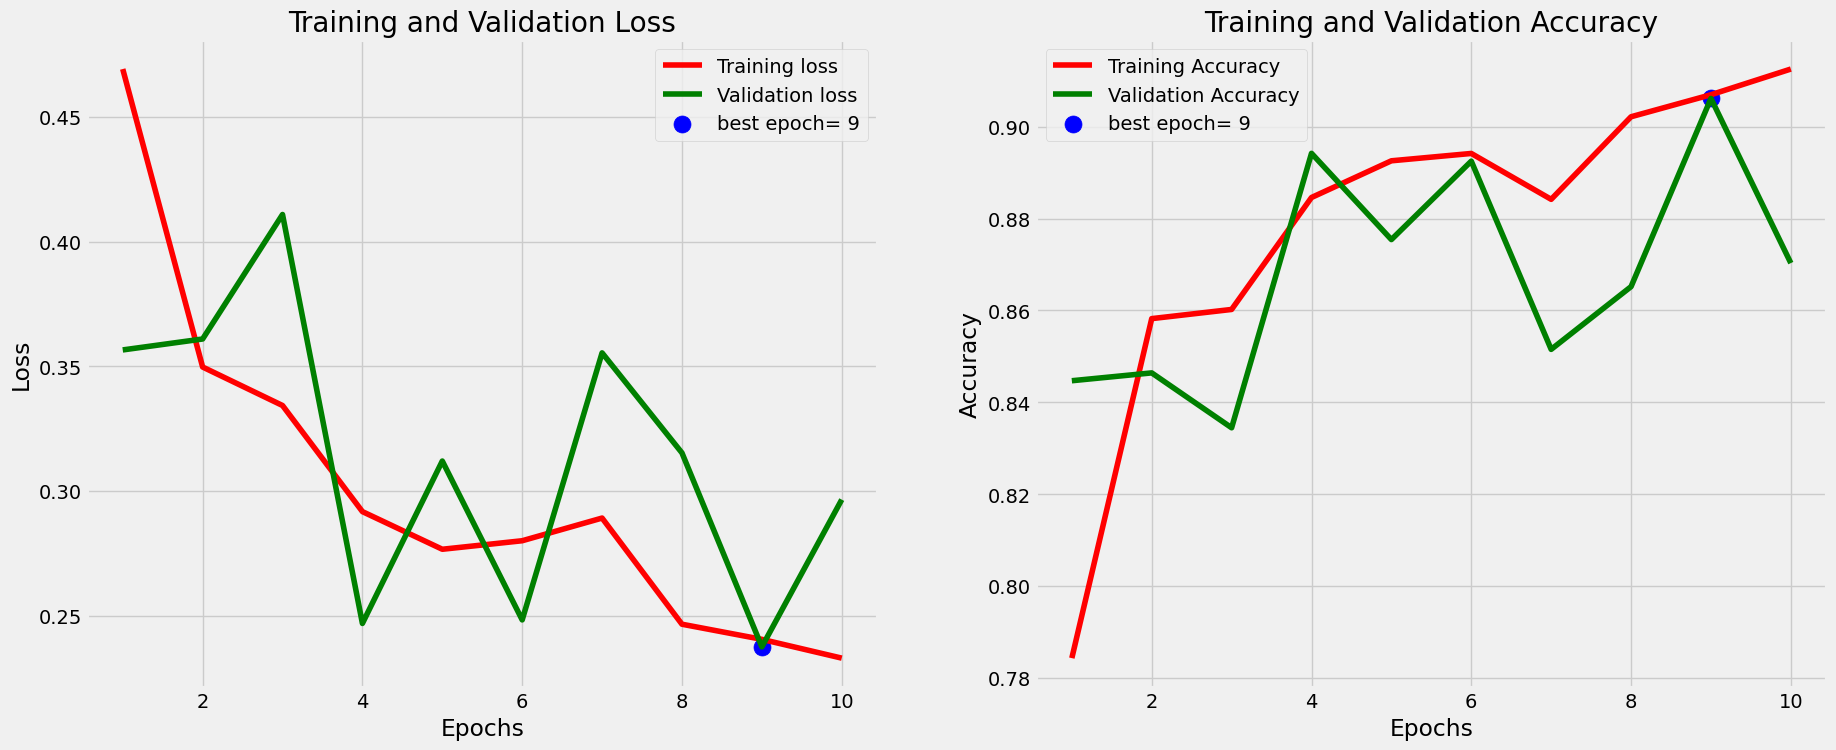

In [126]:
display_training_history(history2, "sparse_categorical_accuracy")

In [127]:
test_loss, test_acc = model2.evaluate(test_gen_binary)

293/293 [==============================] - 4s 12ms/step - loss: 0.2867 - sparse_categorical_accuracy: 0.8805


In [128]:
# Now with a lower learning rate we fine-tune the entire model including the feature extraction layers
# We don't want to make large chages to the feature extraction layers, we just want to fine-tune them for our dataset
# The existing weights are already good at extracting features from images so we don't want to change them too much. unlike the output layer which we want to train to our dataset

for layer in model2.layers:
    layer.trainable= True

model2.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate= 0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

early_stopping= tf.keras.callbacks.EarlyStopping(patience= 3)
history3 = model2.fit(
    x= train_gen_binary,
    epochs= 10,
    verbose= 1, 
    validation_data= valid_gen_binary,
    callbacks= [early_stopping]
)

Epoch 1/10
157/157 [==============================] - 21s 131ms/step - loss: 0.3182 - sparse_categorical_accuracy: 0.8974 - val_loss: 0.1477 - val_sparse_categorical_accuracy: 0.9420
Epoch 2/10
157/157 [==============================] - 20s 130ms/step - loss: 0.1236 - sparse_categorical_accuracy: 0.9513 - val_loss: 0.1544 - val_sparse_categorical_accuracy: 0.9352
Epoch 3/10
157/157 [==============================] - 21s 131ms/step - loss: 0.1022 - sparse_categorical_accuracy: 0.9621 - val_loss: 0.2209 - val_sparse_categorical_accuracy: 0.9113
Epoch 4/10
157/157 [==============================] - 20s 129ms/step - loss: 0.0576 - sparse_categorical_accuracy: 0.9784 - val_loss: 0.1664 - val_sparse_categorical_accuracy: 0.9522


In [129]:
test_loss, test_acc= model2.evaluate(test_gen_binary)

293/293 [==============================] - 4s 12ms/step - loss: 0.0933 - sparse_categorical_accuracy: 0.9744


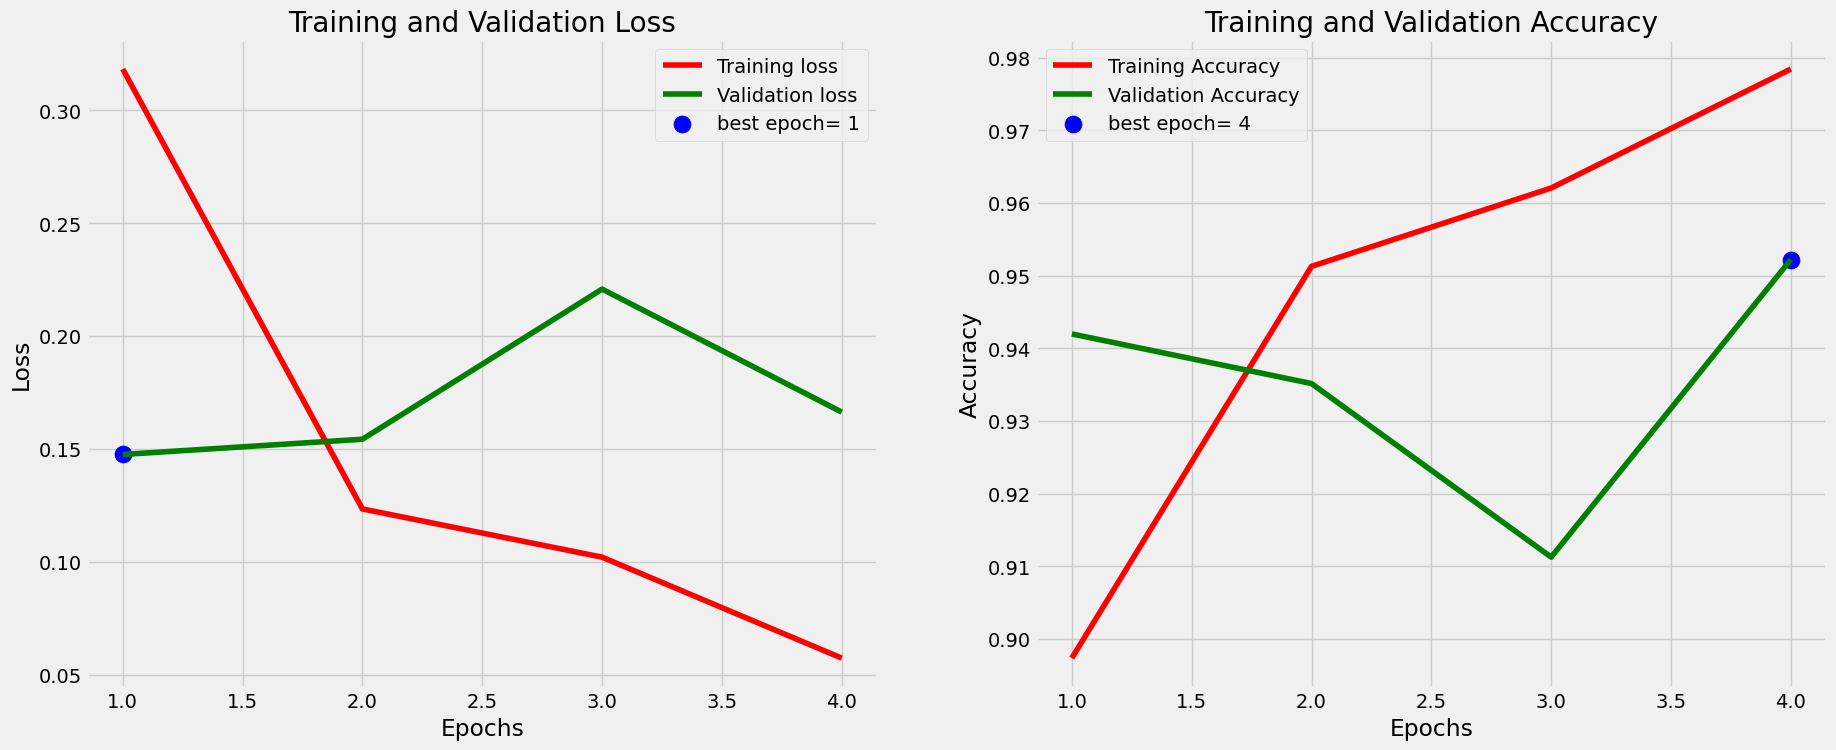

In [130]:
display_training_history(history3, "sparse_categorical_accuracy")

In [131]:
y_pred2 = test_model(test_gen_binary, model2)

293/293 [==============================] - 4s 12ms/step


In [132]:
model2.evaluate(test_gen_binary)

293/293 [==============================] - 4s 13ms/step - loss: 0.0933 - sparse_categorical_accuracy: 0.9744


[0.09325878322124481, 0.9744027853012085]

In [133]:
print(classification_report(test_gen_binary.classes, y_pred2, target_names=classes_binary))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       164
           1       1.00      0.97      0.98       422

    accuracy                           0.97       586
   macro avg       0.96      0.98      0.97       586
weighted avg       0.98      0.97      0.97       586



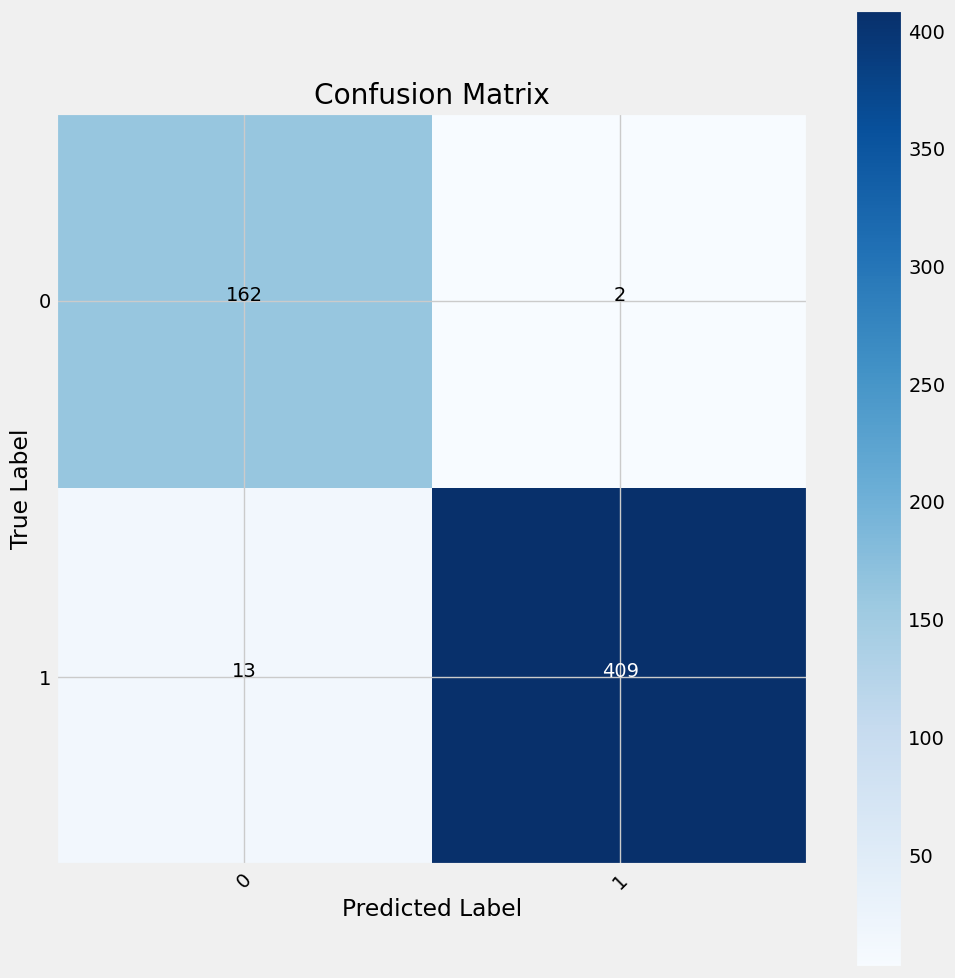

In [134]:
display_test_confusion_matrix(test_gen_binary, y_pred2, classes_binary)

In [135]:
num_samples = valid_gen_binary.n
batch_size = valid_gen_binary.batch_size
num_batches = np.ceil(num_samples / batch_size).astype(int)
random_batch_index = np.random.randint(num_batches)
random_indices = random.sample(range(batch_size), 9)


for i, (images, labels) in enumerate(valid_gen_binary):
    if i == random_batch_index:
        random_images = images[random_indices]
        random_labels = labels[random_indices]
        total_zeros, total_ones = np.sum(random_labels == 0.0), np.sum(random_labels == 1.0)
        print(f"Random batch {i}")
        print(f"Batch indices: {random_indices}")   
        print(f"Batch labels: {labels}")
        print(f"Total Normal: {total_zeros}, Total Pneumonia: {total_ones}")
        break



Random batch 23
Batch indices: [10, 6, 0, 11, 2, 5, 7, 9, 13]
Batch labels: [1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]
Total Normal: 1, Total Pneumonia: 8


In [177]:
explainer = lime_image.LimeImageExplainer()
explanations = []

for i in range(len(random_images)):
    if random_labels[i] == 0.:
        explanations.append(None)
        print(f"Image {i} is NORMAL")
        continue
    explanation = explainer.explain_instance(random_images[i], model2.predict, top_labels=2, hide_color=128, num_samples=2500, num_features=4, batch_size=16)
    explanations.append(explanation)


  0%|          | 0/2500 [00:00<?, ?it/s]

1/1 [==============================] - 0s 19ms/step


  1%|          | 16/2500 [00:00<00:16, 146.12it/s]

1/1 [==============================] - 0s 19ms/step


  1%|▏         | 32/2500 [00:00<00:16, 147.71it/s]

...

1/1 [==============================] - 0s 17ms/step


100%|█████████▉| 2489/2500 [00:14<00:00, 169.88it/s]

1/1 [==============================] - 0s 23ms/step


100%|██████████| 2500/2500 [00:15<00:00, 166.43it/s]

1/1 [==============================] - 0s 15ms/step


In [137]:
raw_prediction

array([[2.546987e-08, 1.000000e+00]], dtype=float32)

1/1 [==============================] - 0s 16ms/step


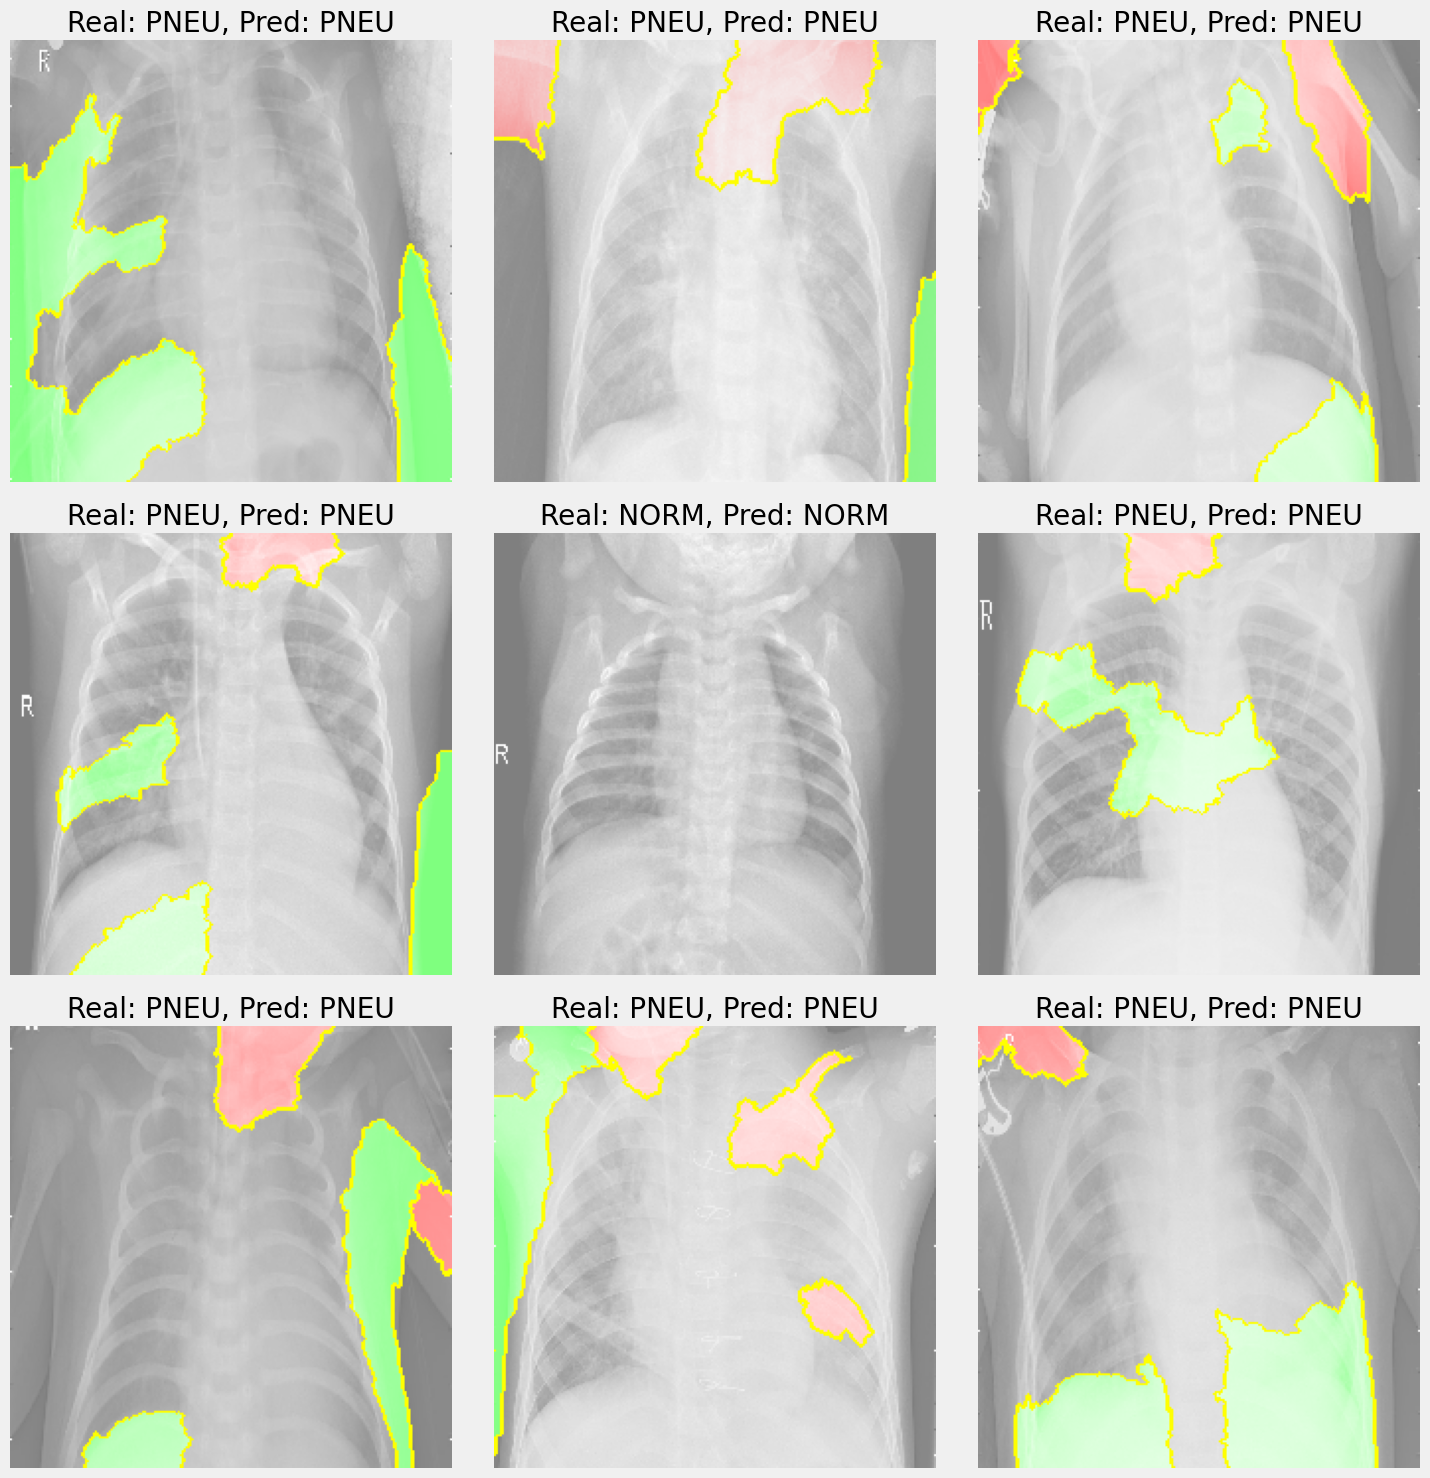

Number of matches: 9 out of 9


In [185]:
matches = 0

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    image = random_images[i]
    explanation = explanations[i]
    raw_prediction = model2.predict(np.expand_dims(image, axis=0))
    real_label = "NORM" if random_labels[i] == 0 else "PNEU"
    pred_label = "NORM" if raw_prediction[0][0] > raw_prediction[0][1] else "PNEU"

    if real_label == "PNEU":
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=4, hide_rest=False)
        ax.imshow(mark_boundaries(temp / 2 + 0.5, mask))
        ax.set_title(f"Real: {real_label}, Pred: {pred_label}")
    else:
        ax.imshow(image / 2 + 0.5)
        ax.set_title(f"Real: {real_label}, Pred: {pred_label}")

    ax.axis('off')
    if np.array_equal(pred_label, real_label):
        matches += 1
plt.tight_layout()
plt.show()
print(f"Number of matches: {matches} out of {len(random_images)}")

Green areas support the predicted result, red areas disprove the predicted result.

The results of the XAI initially caused me concern. The fact that areas outside of the xray are highlighted lead me to believe the model is over fit. After some consideration I don't believe this to be the case as performance on the test and validation data is very similar. If the model was over fit I'd expect much better performance on the validation data used during training which is not the case. I believe this is poor performance of the XAI. However as I combined all the data in the initial data set it would be prudent to verify there's no duplicate data. Next I'll change the model to add drop out layers to help mitigate over fitting which should result in a better performing model.

In [139]:
model2.save('./models/VGG19_' + "{:.4f}".format(test_acc) + '.h5')

To make the model more resilient to overfitting I will remove the output layer and add dropout layers, something which the default vgg19 does not have.
I have still included the binary output layer.

In [140]:
#remove the last layer of the model 
model3 = tf.keras.models.Sequential(vgg19_clone.layers[:-1])
model3.add(Dropout(0.5))
model3.add(Dense(4096, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(4096, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(2, activation='softmax'))


# Set trainable to False except the output layer
for layer in model3.layers[:-1]:
    if not isinstance(layer, Dropout):  # Ensure dropout layers are not set to non-trainable
        layer.trainable = False

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model3.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)      

In [141]:
try:
    early_stopping= tf.keras.callbacks.EarlyStopping(patience= 5)
    history4 = model3.fit(
        train_gen_binary,
        epochs=10,
        verbose=1,
        validation_data=valid_gen_binary,
        callbacks=[early_stopping]
    )
except Exception as e:
    print(f"An error occurred: {e}")

Epoch 1/10
157/157 [==============================] - 21s 131ms/step - loss: 0.4494 - sparse_categorical_accuracy: 0.7891 - val_loss: 0.1487 - val_sparse_categorical_accuracy: 0.9590
Epoch 2/10
157/157 [==============================] - 21s 131ms/step - loss: 0.2550 - sparse_categorical_accuracy: 0.8938 - val_loss: 0.1382 - val_sparse_categorical_accuracy: 0.9539
Epoch 3/10
157/157 [==============================] - 21s 131ms/step - loss: 0.2069 - sparse_categorical_accuracy: 0.9141 - val_loss: 0.1346 - val_sparse_categorical_accuracy: 0.9556
Epoch 4/10
157/157 [==============================] - 21s 132ms/step - loss: 0.1934 - sparse_categorical_accuracy: 0.9185 - val_loss: 0.1269 - val_sparse_categorical_accuracy: 0.9573
Epoch 5/10
157/157 [==============================] - 21s 135ms/step - loss: 0.1888 - sparse_categorical_accuracy: 0.9197 - val_loss: 0.1297 - val_sparse_categorical_accuracy: 0.9556
Epoch 6/10
157/157 [==============================] - 21s 131ms/step - loss: 0.2030 -

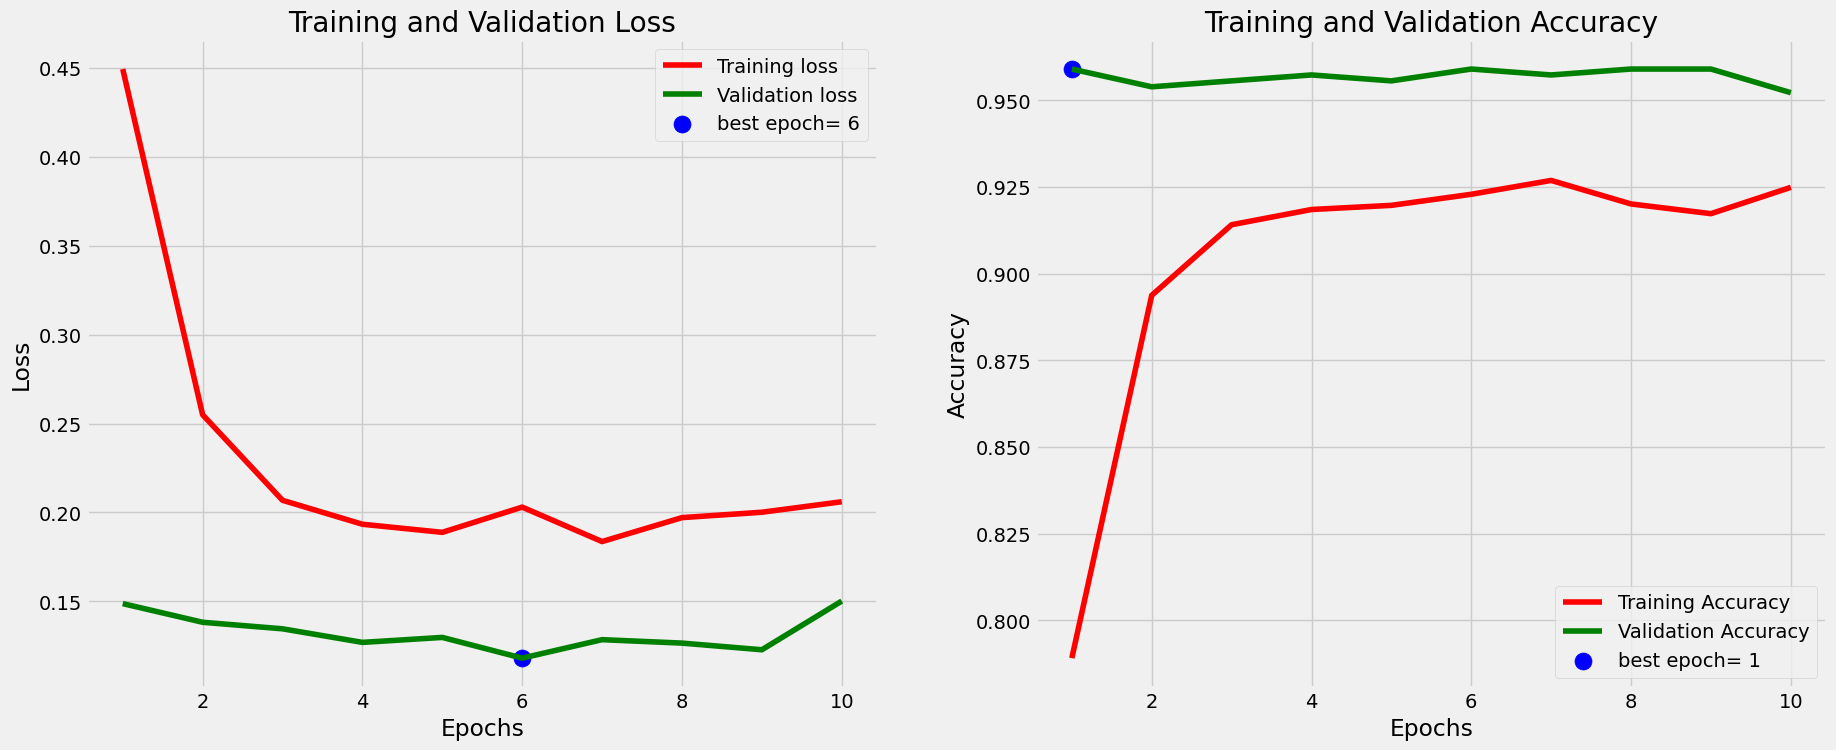

In [142]:
display_training_history(history4, "sparse_categorical_accuracy")

In [143]:
test_loss, test_acc = model3.evaluate(test_gen_binary)

293/293 [==============================] - 4s 12ms/step - loss: 0.0894 - sparse_categorical_accuracy: 0.9710


In [144]:
for layer in model3.layers:
    layer.trainable= True

model3.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate= 0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

early_stopping= tf.keras.callbacks.EarlyStopping(patience= 3)
history5 = model3.fit(
    x= train_gen_binary,
    epochs= 10,
    verbose= 1, 
    validation_data= valid_gen_binary,
    callbacks= [early_stopping]
)

Epoch 1/10
157/157 [==============================] - 21s 130ms/step - loss: 0.1313 - sparse_categorical_accuracy: 0.9533 - val_loss: 0.1302 - val_sparse_categorical_accuracy: 0.9556
Epoch 2/10
157/157 [==============================] - 20s 128ms/step - loss: 0.0970 - sparse_categorical_accuracy: 0.9673 - val_loss: 0.1347 - val_sparse_categorical_accuracy: 0.9522
Epoch 3/10
157/157 [==============================] - 20s 128ms/step - loss: 0.0550 - sparse_categorical_accuracy: 0.9808 - val_loss: 0.0969 - val_sparse_categorical_accuracy: 0.9659
Epoch 4/10
157/157 [==============================] - 20s 129ms/step - loss: 0.0361 - sparse_categorical_accuracy: 0.9884 - val_loss: 0.1384 - val_sparse_categorical_accuracy: 0.9625
Epoch 5/10
157/157 [==============================] - 20s 128ms/step - loss: 0.0404 - sparse_categorical_accuracy: 0.9844 - val_loss: 0.1619 - val_sparse_categorical_accuracy: 0.9727
Epoch 6/10
157/157 [==============================] - 20s 130ms/step - loss: 0.0347 -

In [145]:
test_loss, test_acc= model3.evaluate(test_gen_binary)

293/293 [==============================] - 4s 12ms/step - loss: 0.0866 - sparse_categorical_accuracy: 0.9812


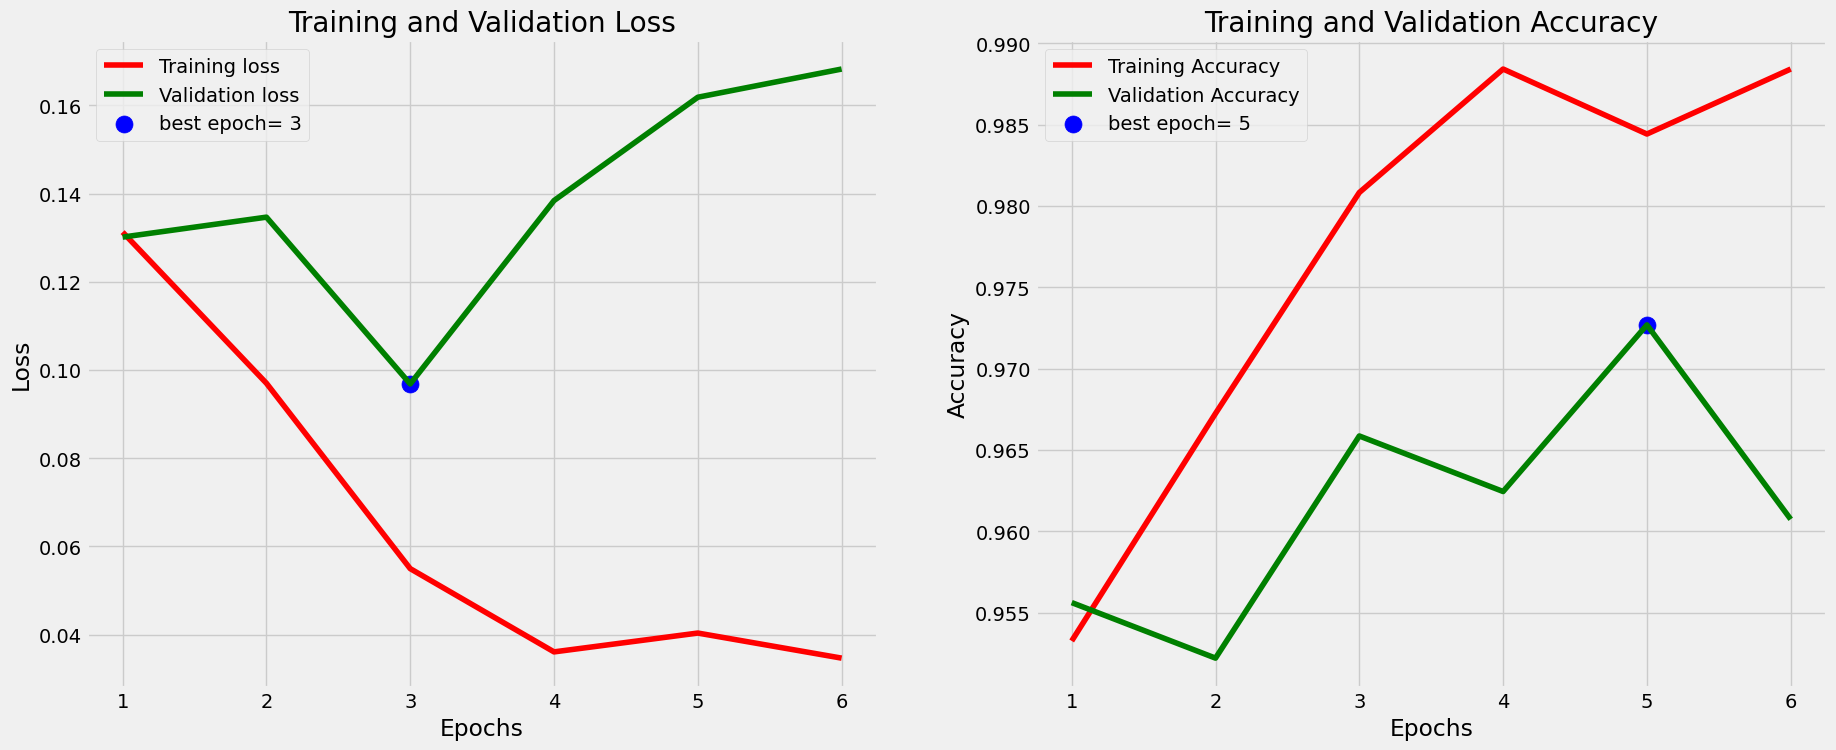

In [146]:
display_training_history(history5, "sparse_categorical_accuracy")

In [147]:
y_pred3 = test_model(test_gen_binary, model3)

293/293 [==============================] - 4s 12ms/step


In [148]:
print(classification_report(test_gen_binary.classes, y_pred3, target_names=classes_binary))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       164
           1       0.99      0.99      0.99       422

    accuracy                           0.98       586
   macro avg       0.98      0.98      0.98       586
weighted avg       0.98      0.98      0.98       586



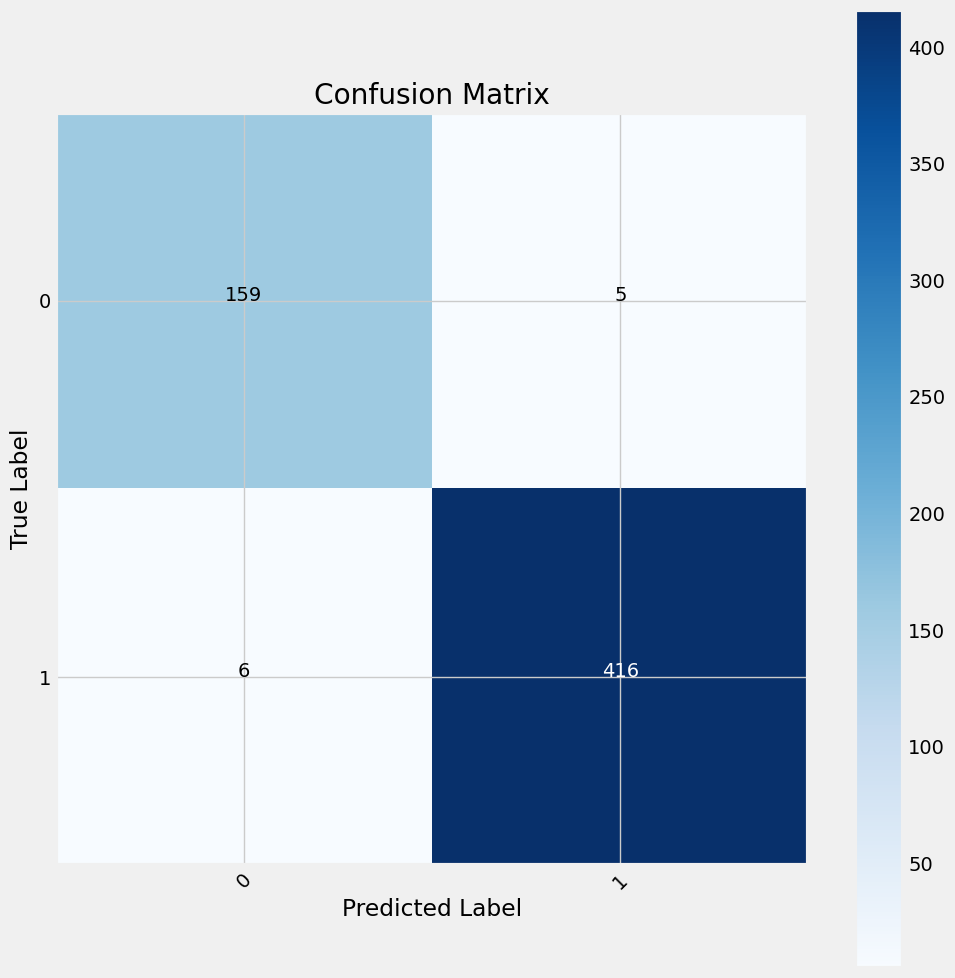

In [149]:
display_test_confusion_matrix(test_gen_binary, y_pred3, classes_binary)

With the added dropout layers at a drop out rate of 50% we see further improved classification performance.

In [150]:
model3.save('./models/VGG19_DROPOUT_' + "{:.4f}".format(test_acc) + '.h5')

https://www.kaggle.com/code/mcarujo/pneumonia-detector-x-ray-dl-cnn-xai # Didn't get scap working, gave up moved onto lime

https://www.kaggle.com/code/martinmauerer/pneumonia-xai

https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20images.ipynb

https://www.kaggle.com/code/kmljts/binary-pneumonia-detection-acc-92-8-resnet18

https://www.kaggle.com/code/cruzangel/transfer-learning-chest-x-ray-images

https://www.kaggle.com/code/romanyn36/chest-xray-pneumonia-classification-93/notebook

https://www.kaggle.com/code/abdallahwagih/pneumonia-detection-efficientnetb0-acc-99/notebook

https://www.kaggle.com/code/sidharkal/image-classification-with-yolov8

https://medium.com/image-processing-with-python/efficientnetb0-architecture-stem-layer-496c7911a62d

https://medium.com/@siddheshb008/vgg-net-architecture-explained-71179310050f

https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/

https://www.tensorflow.org/guide/gpu

https://www.tensorflow.org/guide/keras

https://www.tensorflow.org/guide/basics

https://pandas.pydata.org/docs/reference/frame.html

https://stats.stackexchange.com/questions/326065/cross-entropy-vs-sparse-cross-entropy-when-to-use-one-over-the-other